In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/processed/civilisations_clean.csv")

# Colour palette — one colour per region, used consistently throughout
REGION_COLOURS = {
    'Europe':       '#4E79A7',
    'Middle East':  '#F28E2B',
    'East Asia':    '#E15759',
    'Africa':       '#76B7B2',
    'Americas':     '#59A14F',
    'South Asia':   '#EDC948',
    'Central Asia': '#B07AA1'
}

TRIGGER_COLOURS = {
    'fragmentation':  '#4E79A7',
    'conquest':       '#E15759',
    'overextension':  '#F28E2B',
    'climate':        '#76B7B2',
    'migration':      '#59A14F',
    'economic':       '#EDC948'
}

print(f"Loaded: {df.shape[0]} civilisations, {df.shape[1]} features")
print(f"Year range: {df['founded_year'].min()} to {df['collapse_end_year'].max()}")

Loaded: 112 civilisations, 54 features
Year range: -3000 to 1999


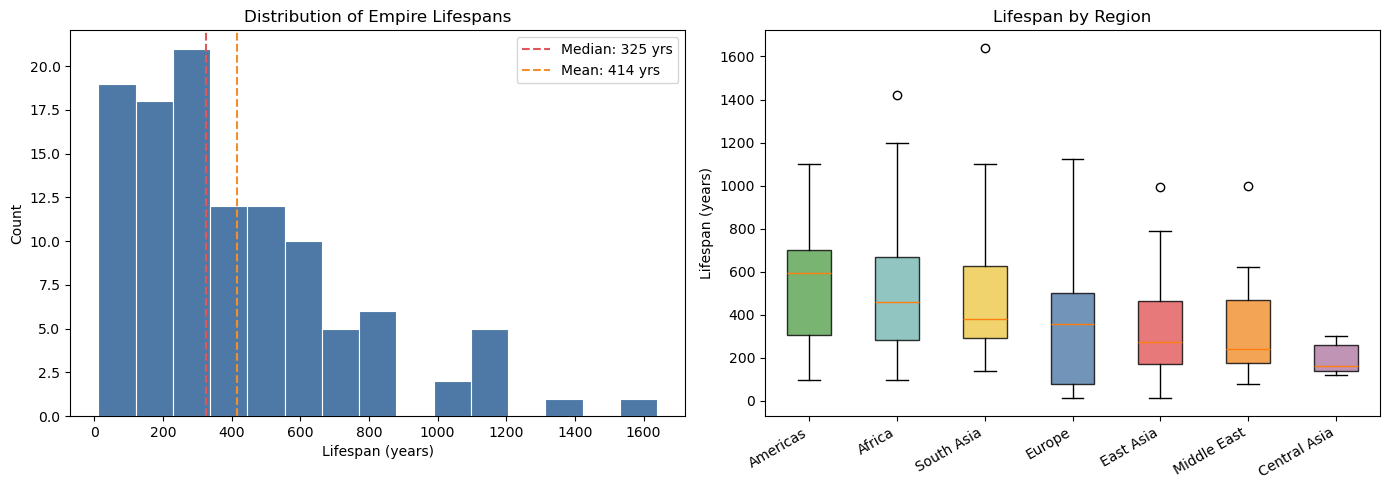

Saved: eda_01_lifespan.png


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Histogram of lifespans
axes[0].hist(df['lifespan_years'], bins=15, color='#4E79A7',
             edgecolor='white', linewidth=0.8)
axes[0].axvline(df['lifespan_years'].median(), color='#E15759',
                linestyle='--', linewidth=1.5, label=f"Median: {df['lifespan_years'].median():.0f} yrs")
axes[0].axvline(df['lifespan_years'].mean(), color='#F28E2B',
                linestyle='--', linewidth=1.5, label=f"Mean: {df['lifespan_years'].mean():.0f} yrs")
axes[0].set_xlabel("Lifespan (years)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Empire Lifespans")
axes[0].legend()

# ── Right: Lifespan by region (boxplot)
region_order = df.groupby('region')['lifespan_years'].median().sort_values(ascending=False).index
data_by_region = [df[df['region'] == r]['lifespan_years'].values for r in region_order]
colours = [REGION_COLOURS[r] for r in region_order]

bp = axes[1].boxplot(data_by_region, patch_artist=True, notch=False)
for patch, colour in zip(bp['boxes'], colours):
    patch.set_facecolor(colour)
    patch.set_alpha(0.8)

axes[1].set_xticklabels(region_order, rotation=30, ha='right')
axes[1].set_ylabel("Lifespan (years)")
axes[1].set_title("Lifespan by Region")

plt.tight_layout()
plt.savefig("../data/processed/eda_01_lifespan.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_01_lifespan.png")

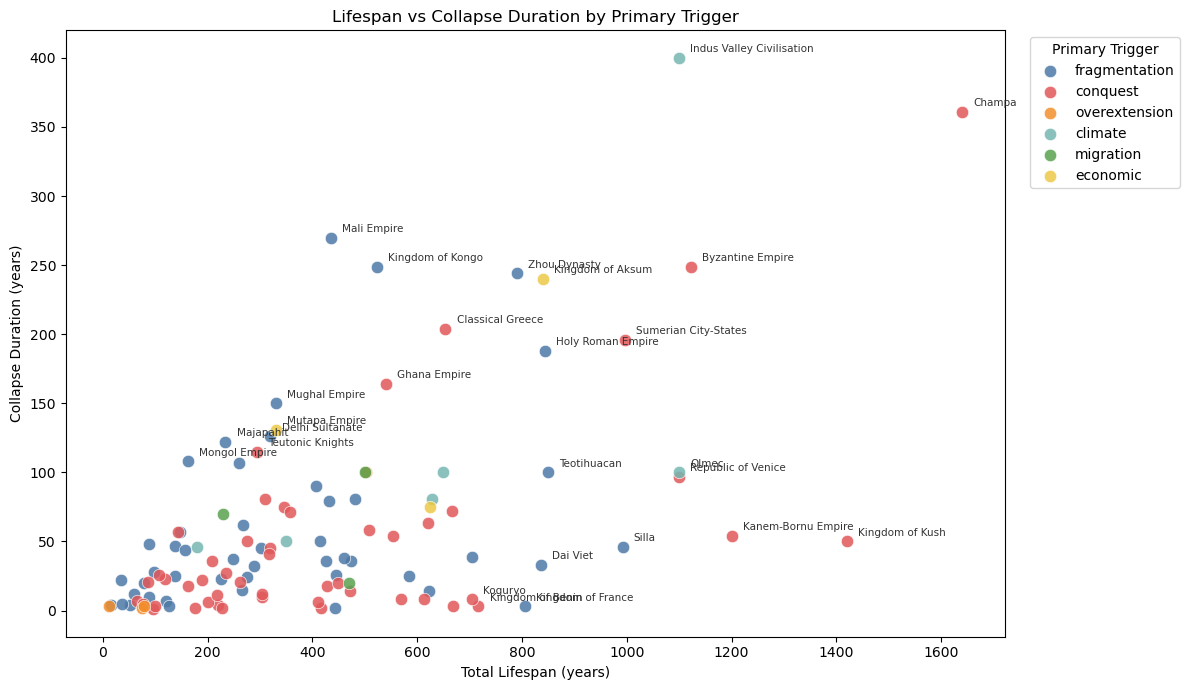

Saved: eda_02_lifespan_vs_collapse.png


In [3]:
fig, ax = plt.subplots(figsize=(12, 7))

for trigger, colour in TRIGGER_COLOURS.items():
    subset = df[df['primary_collapse_trigger'] == trigger]
    ax.scatter(subset['lifespan_years'], subset['collapse_duration_years'],
               c=colour, label=trigger, s=80, alpha=0.85, edgecolors='white', linewidth=0.5)

# Annotate outliers
outlier_threshold_x = df['lifespan_years'].quantile(0.85)
outlier_threshold_y = df['collapse_duration_years'].quantile(0.85)
outliers = df[
    (df['lifespan_years'] > outlier_threshold_x) |
    (df['collapse_duration_years'] > outlier_threshold_y)
]
for _, row in outliers.iterrows():
    ax.annotate(row['name'],
                xy=(row['lifespan_years'], row['collapse_duration_years']),
                xytext=(8, 4), textcoords='offset points',
                fontsize=7.5, color='#333333')

ax.set_xlabel("Total Lifespan (years)")
ax.set_ylabel("Collapse Duration (years)")
ax.set_title("Lifespan vs Collapse Duration by Primary Trigger")
ax.legend(title="Primary Trigger", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig("../data/processed/eda_02_lifespan_vs_collapse.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_02_lifespan_vs_collapse.png")

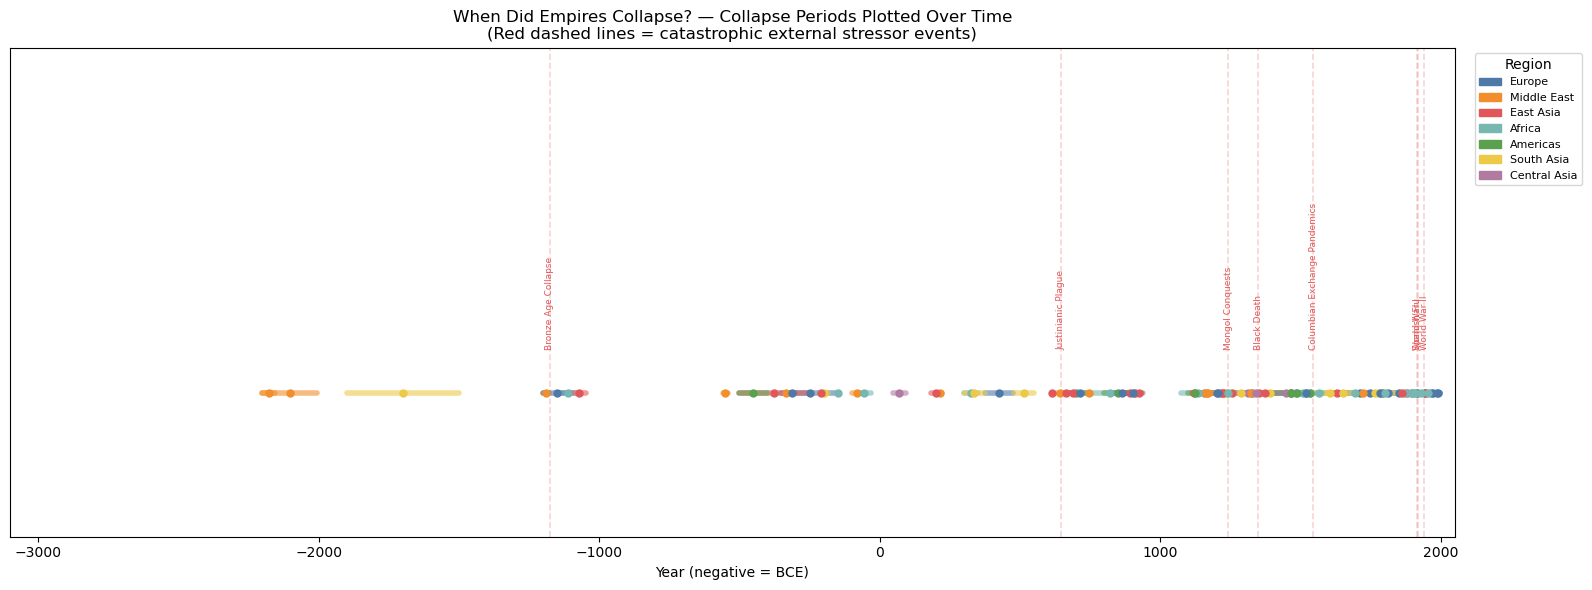

Saved: eda_03_collapse_timeline.png


In [4]:
fig, ax = plt.subplots(figsize=(16, 6))

# Plot each civilisation as a horizontal line from collapse_start to collapse_end
for _, row in df.iterrows():
    colour = REGION_COLOURS.get(row['region'], '#999999')
    ax.plot(
        [row['collapse_start_year'], row['collapse_end_year']],
        [0, 0],
        color=colour, linewidth=4, alpha=0.6, solid_capstyle='round'
    )
    # Mark collapse midpoint
    midpoint = (row['collapse_start_year'] + row['collapse_end_year']) / 2
    ax.scatter(midpoint, 0, color=colour, s=25, zorder=5)

# Add stressor event markers
stressors = pd.read_csv("../data/raw/external_stressors.csv")
catastrophic = stressors[stressors['severity'] == 'catastrophic']

for _, event in catastrophic.iterrows():
    mid = (event['start_year'] + event['end_year']) / 2
    ax.axvline(mid, color='#E15759', alpha=0.25, linewidth=1.2, linestyle='--')
    ax.text(mid, 0.015, event['event_name'],
            rotation=90, fontsize=6.5, color='#E15759',
            ha='center', va='bottom')

# X axis formatting
ax.set_xlim(-3100, 2050)
ax.set_ylim(-0.05, 0.12)
ax.set_xlabel("Year (negative = BCE)")
ax.set_title("When Did Empires Collapse? — Collapse Periods Plotted Over Time\n"
             "(Red dashed lines = catastrophic external stressor events)")
ax.set_yticks([])

# Region legend
patches = [mpatches.Patch(color=v, label=k) for k, v in REGION_COLOURS.items()]
ax.legend(handles=patches, bbox_to_anchor=(1.01, 1), loc='upper left',
          title="Region", fontsize=8)

plt.tight_layout()
plt.savefig("../data/processed/eda_03_collapse_timeline.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_03_collapse_timeline.png")

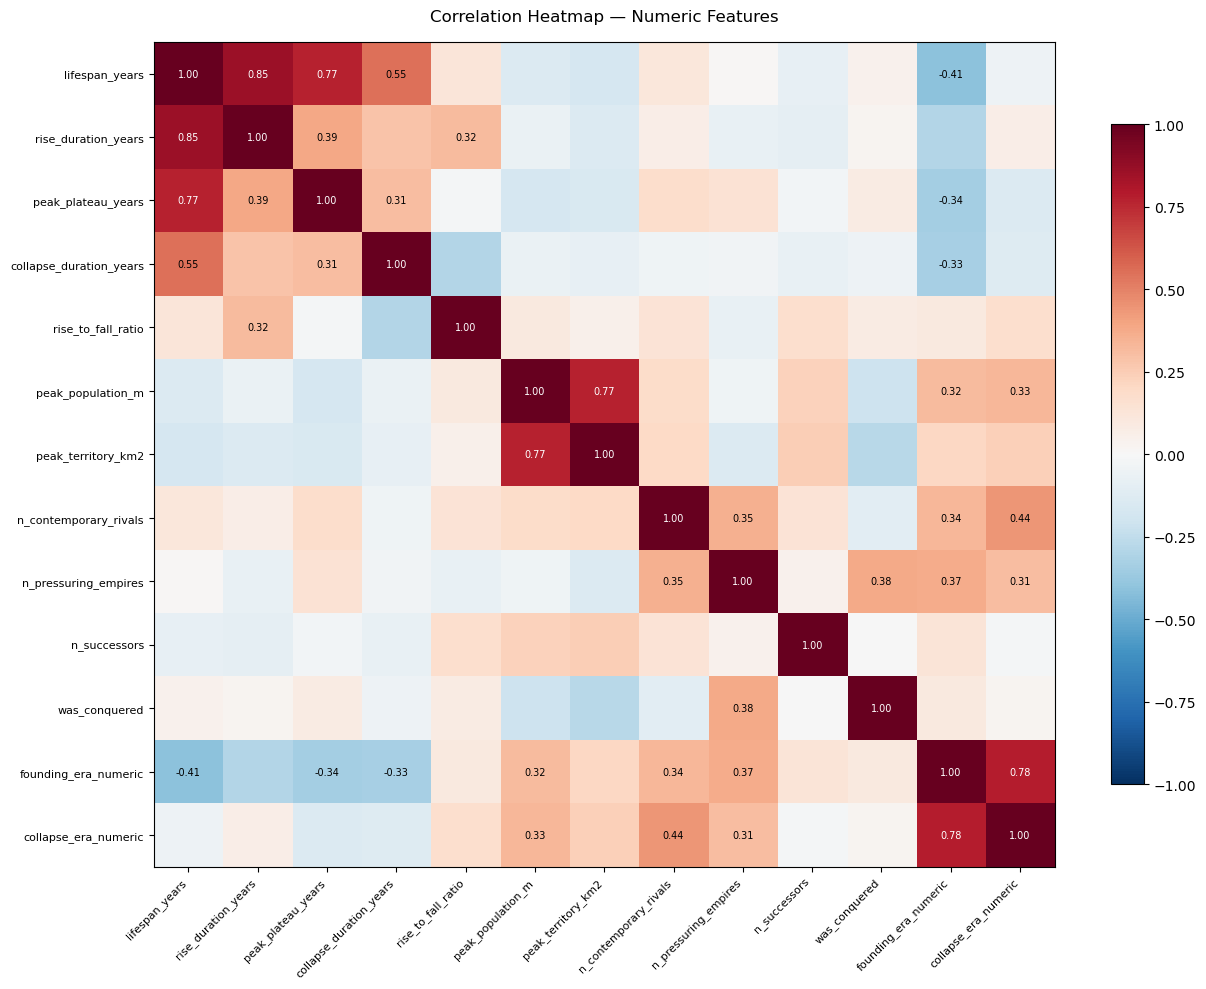

Saved: eda_04_correlation.png


In [5]:
numeric_features = [
    'lifespan_years', 'rise_duration_years', 'peak_plateau_years',
    'collapse_duration_years', 'rise_to_fall_ratio',
    'peak_population_m', 'peak_territory_km2',
    'n_contemporary_rivals', 'n_pressuring_empires',
    'n_successors', 'was_conquered',
    'founding_era_numeric', 'collapse_era_numeric'
]

corr = df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(13, 10))

im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks(range(len(numeric_features)))
ax.set_yticks(range(len(numeric_features)))
ax.set_xticklabels(numeric_features, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(numeric_features, fontsize=8)

# Annotate cells
for i in range(len(numeric_features)):
    for j in range(len(numeric_features)):
        val = corr.iloc[i, j]
        if abs(val) > 0.3:
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=7, color='white' if abs(val) > 0.6 else 'black')

ax.set_title("Correlation Heatmap — Numeric Features", pad=15)
plt.tight_layout()
plt.savefig("../data/processed/eda_04_correlation.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_04_correlation.png")

In [6]:
print("=" * 60)
print("EDA SUMMARY — KEY FINDINGS")
print("=" * 60)

print("\n── LIFESPAN ──")
print(f"Shortest lived: {df.nsmallest(3, 'lifespan_years')[['name','lifespan_years']].to_string(index=False)}")
print(f"Longest lived:  {df.nlargest(3, 'lifespan_years')[['name','lifespan_years']].to_string(index=False)}")

print("\n── COLLAPSE SPEED ──")
print(f"Fastest collapse: {df.nsmallest(3, 'collapse_duration_years')[['name','collapse_duration_years']].to_string(index=False)}")
print(f"Slowest collapse: {df.nlargest(3, 'collapse_duration_years')[['name','collapse_duration_years']].to_string(index=False)}")

print("\n── RISE TO FALL RATIO ──")
print(f"Rose fastest relative to fall:")
print(df.nlargest(3, 'rise_to_fall_ratio')[['name','rise_duration_years','collapse_duration_years','rise_to_fall_ratio']].to_string(index=False))
print(f"\nFell faster than they rose:")
print(df[df['rise_to_fall_ratio'] < 1][['name','rise_duration_years','collapse_duration_years','rise_to_fall_ratio']].to_string(index=False))

print("\n── COLLAPSE TRIGGER BREAKDOWN ──")
trigger_counts = df['primary_collapse_trigger'].value_counts()
for trigger, count in trigger_counts.items():
    pct = count / len(df) * 100
    avg_lifespan = df[df['primary_collapse_trigger'] == trigger]['lifespan_years'].mean()
    print(f"  {trigger:<16} {count:>3} ({pct:.0f}%)  avg lifespan: {avg_lifespan:.0f} yrs")

print("\n── CONQUEST VS INTERNAL COLLAPSE ──")
conquered = df[df['was_conquered'] == 1]
internal = df[df['was_conquered'] == 0]
print(f"Conquered empires:      {len(conquered)} — avg lifespan: {conquered['lifespan_years'].mean():.0f} yrs")
print(f"Internal collapse:      {len(internal)} — avg lifespan: {internal['lifespan_years'].mean():.0f} yrs")

print("\n── NOTABLE CORRELATIONS TO INVESTIGATE ──")
corr_pairs = []
for i in range(len(numeric_features)):
    for j in range(i+1, len(numeric_features)):
        val = corr.iloc[i, j]
        if abs(val) > 0.4:
            corr_pairs.append((numeric_features[i], numeric_features[j], val))

corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for a, b, v in corr_pairs[:8]:
    direction = "positive" if v > 0 else "negative"
    print(f"  {a} vs {b}: {v:.2f} ({direction})")

print("\n── ERA DISTRIBUTION ──")
for era in ['Bronze Age', 'Classical', 'Medieval', 'Early Modern', 'Industrial', 'Modern']:
    subset = df[df['founding_era'] == era]
    if len(subset) > 0:
        print(f"  {era:<15} {len(subset):>2} empires  avg lifespan: {subset['lifespan_years'].mean():.0f} yrs")

EDA SUMMARY — KEY FINDINGS

── LIFESPAN ──
Shortest lived:              name  lifespan_years
Napoleonic Empire              11
      Qin Dynasty              15
Macedonian Empire              35
Longest lived:                name  lifespan_years
            Champa            1640
   Kingdom of Kush            1420
Kanem-Bornu Empire            1200

── COLLAPSE SPEED ──
Fastest collapse:                          name  collapse_duration_years
                  Inca Empire                        1
                 Aztec Empire                        2
German Empire and Third Reich                        2
Slowest collapse:                      name  collapse_duration_years
Indus Valley Civilisation                      400
                   Champa                      361
              Mali Empire                      270

── RISE TO FALL RATIO ──
Rose fastest relative to fall:
                   name  rise_duration_years  collapse_duration_years  rise_to_fall_ratio
      Kingdom of Fra